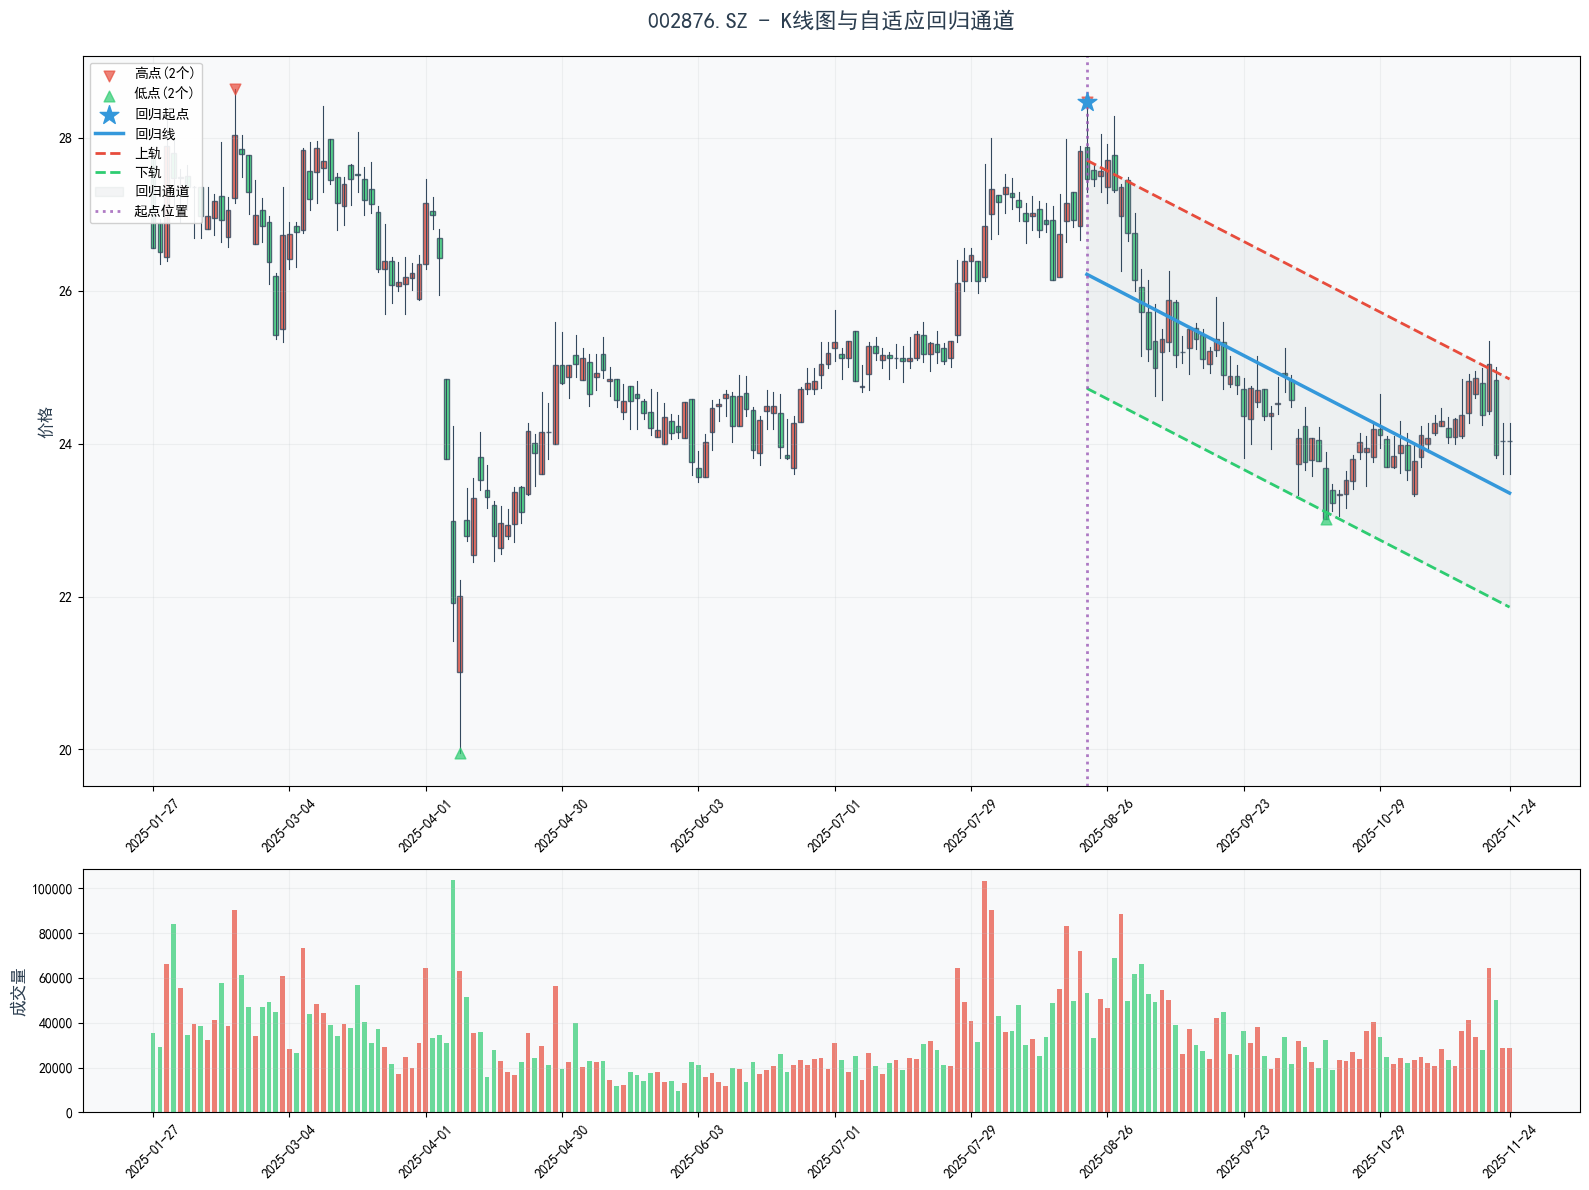

自适应回归通道统计信息:
起点类型: high
起点日期: 2025-08-21
起点价格: 28.48
回归质量评分: 0.7555
回归线斜率: -0.046201
R²值: 0.5586
当前价格: 24.04
上轨值: 24.85
下轨值: 21.86
回归线值: 23.36
通道宽度: 2.99


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from scipy.signal import argrelextrema
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体和图表样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False   # 用来正常显示负号

class AdaptiveRegressionChannel:
    def __init__(self, lookback_period=20, std_multiplier=2, min_trend_length=10):
        """
        初始化自适应回归通道
        
        参数:
        lookback_period (int): 寻找极值点的回溯周期
        std_multiplier (float): 标准差乘数
        min_trend_length (int): 最小趋势长度
        """
        self.lookback_period = lookback_period
        self.std_multiplier = std_multiplier
        self.min_trend_length = min_trend_length
        
    def find_extreme_points(self, high_prices, low_prices):
        """
        使用科学方法寻找极高点和极低点
        
        参数:
        high_prices (array-like): 最高价序列
        low_prices (array-like): 最低价序列
        
        返回:
        tuple: (high_points, low_points) 极高点和极低点的索引和值
        """
        # 使用scipy的argrelextrema函数寻找局部极值点
        high_indices = argrelextrema(high_prices, np.greater, order=self.lookback_period)[0]
        low_indices = argrelextrema(low_prices, np.less, order=self.lookback_period)[0]
        
        high_points = [(i, high_prices[i]) for i in high_indices]
        low_points = [(i, low_prices[i]) for i in low_indices]
        
        return high_points, low_points
    
    def evaluate_regression_quality(self, prices, start_idx):
        """
        评估回归质量
        
        参数:
        prices (array-like): 价格序列
        start_idx (int): 起始索引
        
        返回:
        float: 回归质量评分 (0-1)
        """
        if start_idx >= len(prices) - self.min_trend_length:
            return 0
            
        # 从起点到当前点的数据
        segment_prices = prices[start_idx:]
        
        # 准备数据
        X = np.arange(len(segment_prices)).reshape(-1, 1)
        y = np.array(segment_prices).reshape(-1, 1)
        
        # 计算线性回归
        model = LinearRegression()
        model.fit(X, y)
        
        # 回归线
        regression_line = model.predict(X).flatten()
        
        # 计算残差和标准差
        residuals = y.flatten() - regression_line
        std = np.std(residuals)
        
        # 计算R²值
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y.flatten() - np.mean(y.flatten()))**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        
        # 计算价格在通道内的比例
        upper_band = regression_line + self.std_multiplier * std
        lower_band = regression_line - self.std_multiplier * std
        
        in_channel = np.sum((segment_prices >= lower_band) & (segment_prices <= upper_band))
        channel_ratio = in_channel / len(segment_prices)
        
        # 综合评分：R²和通道内比例的平均值
        quality_score = (r_squared + channel_ratio) / 2
        
        return quality_score
    
    def find_best_regression_start(self, close_prices, high_points, low_points):
        """
        寻找最佳的回归起点
        
        参数:
        close_prices (array-like): 收盘价序列
        high_points: 极高点列表
        low_points: 极低点列表
        
        返回:
        dict: 包含最佳起点信息
        """
        # 合并所有极值点并按时间排序
        all_extremes = []
        for idx, price in high_points:
            all_extremes.append((idx, price, 'high'))
        for idx, price in low_points:
            all_extremes.append((idx, price, 'low'))
        
        # 按索引排序
        all_extremes.sort(key=lambda x: x[0])
        
        # 确保有足够的极值点
        if len(all_extremes) < 2:
            # 如果没有足够的极值点，使用序列起点
            return {
                'start_index': 0,
                'start_price': close_prices[0],
                'start_type': 'start',
                'quality_score': 0.5
            }
        
        # 评估每个可能的起点
        candidate_scores = []
        for extreme in all_extremes:
            if extreme[0] <= len(close_prices) - self.min_trend_length:
                score = self.evaluate_regression_quality(close_prices, extreme[0])
                candidate_scores.append((extreme, score))
        
        # 如果没有合适的候选点，使用序列起点
        if not candidate_scores:
            return {
                'start_index': 0,
                'start_price': close_prices[0],
                'start_type': 'start',
                'quality_score': 0.5
            }
        
        # 选择评分最高的起点
        best_candidate = max(candidate_scores, key=lambda x: x[1])
        best_extreme, best_score = best_candidate
        
        return {
            'start_index': best_extreme[0],
            'start_price': best_extreme[1],
            'start_type': best_extreme[2],
            'quality_score': best_score
        }
    
    def calculate_regression_channel(self, prices, start_index):
        """
        计算线性回归通道
        
        参数:
        prices (array-like): 价格序列
        start_index (int): 起始索引
        
        返回:
        dict: 包含回归线、上轨、下轨的字典
        """
        if start_index >= len(prices):
            raise ValueError("起点索引超出价格序列范围")
        
        # 从起点到当前点的数据
        start_idx = start_index
        end_idx = len(prices)
        segment_prices = prices[start_idx:end_idx]
        
        if len(segment_prices) < 2:
            raise ValueError("从起点开始的数据点太少，无法计算回归")
        
        # 准备数据
        X = np.arange(len(segment_prices)).reshape(-1, 1)
        y = np.array(segment_prices).reshape(-1, 1)
        
        # 计算线性回归
        model = LinearRegression()
        model.fit(X, y)
        
        # 回归线
        regression_line = model.predict(X).flatten()
        
        # 计算残差和标准差
        residuals = y.flatten() - regression_line
        std = np.std(residuals)
        
        # 计算上下轨
        upper_band = regression_line + self.std_multiplier * std
        lower_band = regression_line - self.std_multiplier * std
        
        # 计算R²值
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y.flatten() - np.mean(y.flatten()))**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        
        return {
            'regression_line': regression_line,
            'upper_band': upper_band,
            'lower_band': lower_band,
            'slope': model.coef_[0][0],
            'intercept': model.intercept_[0],
            'r_squared': r_squared,
            'start_index': start_idx,
            'end_index': end_idx - 1
        }
    
    def get_adaptive_regression(self, close_prices, high_prices, low_prices):
        """
        获取自适应回归通道
        
        参数:
        close_prices (array-like): 收盘价序列
        high_prices (array-like): 最高价序列
        low_prices (array-like): 最低价序列
        
        返回:
        dict: 包含回归通道信息和起点信息的字典
        """
        if len(close_prices) < self.min_trend_length:
            raise ValueError(f"价格序列长度({len(close_prices)})小于最小趋势长度({self.min_trend_length})")
        
        # 寻找极值点
        high_points, low_points = self.find_extreme_points(high_prices, low_prices)
        
        # 寻找最佳回归起点
        start_info = self.find_best_regression_start(close_prices, high_points, low_points)
        
        # 计算回归通道
        regression_result = self.calculate_regression_channel(
            close_prices, start_info['start_index']
        )
        
        return {
            'regression': regression_result,
            'start_info': start_info,
            'all_high_points': high_points,
            'all_low_points': low_points
        }
    
    def plot_kline_with_regression(self, df, title="K线图与自适应回归通道"):
        """
        绘制K线图与自适应回归通道
        
        参数:
        df (DataFrame): 包含OHLC(V)数据的DataFrame，列名应为小写
        title (str): 图表标题
        """
        # 检查必要的列是否存在
        required_columns = ['open', 'high', 'low', 'close']
        missing_columns = [col for col in required_columns if col not in df.columns]
        if missing_columns:
            raise ValueError(f"数据框缺少必要的列: {missing_columns}")
        
        # 提取数据
        dates = df.index
        open_prices = df['open'].values
        high_prices = df['high'].values
        low_prices = df['low'].values
        close_prices = df['close'].values
        volume = df['volume'].values if 'volume' in df.columns else None
        
        # 计算自适应回归通道
        try:
            results = self.get_adaptive_regression(close_prices, high_prices, low_prices)
        except Exception as e:
            print(f"计算回归通道时出错: {e}")
            return
        
        regression = results['regression']
        start_info = results['start_info']
        all_high_points = results['all_high_points']
        all_low_points = results['all_low_points']
        
        # 创建图表
        if volume is not None:
            # 如果有成交量数据，创建两个子图
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), 
                                          gridspec_kw={'height_ratios': [3, 1]})
        else:
            # 如果没有成交量数据，只创建一个图
            fig, ax1 = plt.subplots(figsize=(16, 10))
            ax2 = None
        
        # 设置淡雅风格
        fig.patch.set_facecolor('white')
        ax1.set_facecolor('#f8f9fa')
        if ax2 is not None:
            ax2.set_facecolor('#f8f9fa')
        
        # 使用整数索引而不是日期，避免空白
        x_values = np.arange(len(dates))
        
        # 绘制K线
        self._plot_candlestick(ax1, x_values, open_prices, high_prices, low_prices, close_prices)
        
        # 标记所有极值点 - 修复变量名错误
        high_indices = [i for i, _ in all_high_points]
        high_values = [v for _, v in all_high_points]
        ax1.scatter(high_indices, high_values, color='#e74c3c', marker='v', s=60, 
                   label=f'高点({len(all_high_points)}个)', zorder=5, alpha=0.7)
        
        low_indices = [i for i, _ in all_low_points]
        low_values = [v for _, v in all_low_points]
        ax1.scatter(low_indices, low_values, color='#2ecc71', marker='^', s=60, 
                   label=f'低点({len(all_low_points)}个)', zorder=5, alpha=0.7)
        
        # 标记回归起点
        start_idx = start_info['start_index']
        ax1.scatter([start_idx], [start_info['start_price']], 
                   color='#3498db', 
                   marker='*', 
                   s=200, label='回归起点', zorder=6)
        
        # 绘制回归通道
        start_idx_reg = regression['start_index']
        end_idx = regression['end_index']
        
        # 创建索引切片
        x_slice = np.arange(start_idx_reg, end_idx+1)
        
        # 绘制回归线和通道
        ax1.plot(x_slice, regression['regression_line'], 
                label='回归线', color='#3498db', linewidth=2.5)
        ax1.plot(x_slice, regression['upper_band'], 
                label='上轨', color='#e74c3c', linestyle='--', linewidth=2)
        ax1.plot(x_slice, regression['lower_band'], 
                label='下轨', color='#2ecc71', linestyle='--', linewidth=2)
        
        # 填充通道区域
        ax1.fill_between(x_slice, regression['upper_band'], regression['lower_band'], 
                        alpha=0.1, color='#95a5a6', label='回归通道')
        
        # 添加垂直线标记回归起点位置
        ax1.axvline(x=start_idx, color='#9b59b6', linestyle=':', alpha=0.8, 
                   linewidth=2, label='起点位置')
        
        # 设置主图属性
        ax1.set_title(title, fontsize=16, fontweight='bold', pad=20, color='#2c3e50')
        ax1.set_ylabel('价格', fontsize=12, color='#2c3e50')
        ax1.legend(loc='upper left', fontsize=10, framealpha=0.9)
        ax1.grid(True, alpha=0.2, color='#bdc3c7')
        
        # 设置x轴刻度为日期标签
        # 选择适量的刻度点，避免过于拥挤
        n_ticks = min(10, len(dates))
        step = max(1, len(dates) // n_ticks)
        tick_indices = list(range(0, len(dates), step))
        if len(dates) - 1 not in tick_indices:
            tick_indices.append(len(dates) - 1)
        
        tick_labels = [dates[i].strftime('%Y-%m-%d') for i in tick_indices]
        ax1.set_xticks(tick_indices)
        ax1.set_xticklabels(tick_labels)
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, fontsize=10)
        
        # 如果有成交量，绘制成交量
        if ax2 is not None and volume is not None:
            self._plot_volume(ax2, x_values, volume, close_prices, open_prices)
            ax2.set_ylabel('成交量', fontsize=12, color='#2c3e50')
            ax2.grid(True, alpha=0.2, color='#bdc3c7')
            ax2.set_xticks(tick_indices)
            ax2.set_xticklabels(tick_labels)
            plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
        # 打印统计信息
        self._print_statistics(regression, start_info, dates[start_idx], close_prices)
    
    def _plot_candlestick(self, ax, x_values, open_prices, high_prices, low_prices, close_prices):
        """
        绘制K线图
        
        参数:
        ax: matplotlib轴对象
        x_values: x轴数值序列
        open_prices: 开盘价序列
        high_prices: 最高价序列
        low_prices: 最低价序列
        close_prices: 收盘价序列
        """
        # 计算每个K线的宽度
        width = 0.7
        
        # 绘制每个K线
        for i, x_val in enumerate(x_values):
            open_price = open_prices[i]
            high_price = high_prices[i]
            low_price = low_prices[i]
            close_price = close_prices[i]
            
            # 确定颜色：上涨为红色，下跌为绿色
            color = '#e74c3c' if close_price >= open_price else '#2ecc71'
            
            # 绘制上下影线
            ax.plot([x_val, x_val], [low_price, high_price], color='#34495e', linewidth=0.8)
            
            # 绘制实体
            rect = Rectangle(
                (x_val - width/2, min(open_price, close_price)),
                width,
                abs(close_price - open_price),
                facecolor=color,
                edgecolor='#34495e',
                alpha=0.8
            )
            ax.add_patch(rect)
    
    def _plot_volume(self, ax, x_values, volume, close_prices, open_prices):
        """
        绘制成交量
        
        参数:
        ax: matplotlib轴对象
        x_values: x轴数值序列
        volume: 成交量序列
        close_prices: 收盘价序列
        open_prices: 开盘价序列
        """
        # 计算每个柱状图的宽度
        width = 0.7
        
        # 为每个成交量柱设置颜色
        colors = ['#e74c3c' if close_prices[i] >= open_prices[i] else '#2ecc71' for i in range(len(x_values))]
        
        # 绘制成交量柱状图
        for i, x_val in enumerate(x_values):
            ax.bar(x_val, volume[i], width=width, color=colors[i], alpha=0.7)
        
        ax.set_ylabel('成交量', fontsize=12, color='#2c3e50')
        ax.grid(True, alpha=0.2, color='#bdc3c7')
    
    def _print_statistics(self, regression, start_info, start_date, close_prices):
        """
        打印统计信息
        
        参数:
        regression: 回归通道结果
        start_info: 起点信息
        start_date: 起点日期
        close_prices: 收盘价序列
        """
        print("=" * 50)
        print("自适应回归通道统计信息:")
        print("=" * 50)
        print(f"起点类型: {start_info['start_type']}")
        print(f"起点日期: {start_date.strftime('%Y-%m-%d')}")
        print(f"起点价格: {start_info['start_price']:.2f}")
        print(f"回归质量评分: {start_info['quality_score']:.4f}")
        print(f"回归线斜率: {regression['slope']:.6f}")
        print(f"R²值: {regression['r_squared']:.4f}")
        print(f"当前价格: {close_prices[-1]:.2f}")
        print(f"上轨值: {regression['upper_band'][-1]:.2f}")
        print(f"下轨值: {regression['lower_band'][-1]:.2f}")
        print(f"回归线值: {regression['regression_line'][-1]:.2f}")
        print(f"通道宽度: {regression['upper_band'][-1] - regression['lower_band'][-1]:.2f}")
        print("=" * 50)


# 使用示例
if __name__ == "__main__":
    # 数据加载
    ts_code = "002876.SZ"
    csv_path = fr'E:\stock\csv_version\analysis_results\{ts_code}_analysis.csv'    
    df = pd.read_csv(csv_path, index_col='trade_date', parse_dates=['trade_date']).sort_index(ascending=True).tail(200)
    
    # 创建自适应回归通道对象
    adaptive_rc = AdaptiveRegressionChannel(
        lookback_period=80, 
        std_multiplier=2, 
        min_trend_length=20
    )
    
    # 绘制K线图与回归通道
    adaptive_rc.plot_kline_with_regression(
        df=df,
        title=f"{ts_code} - K线图与自适应回归通道"
    )